<a href="https://colab.research.google.com/github/mrabinayaa/DAAexps/blob/main/exp10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Input Type          DQS Comp      DQS Time    RQS Comp      RQS Time
----------------------------------------------------------------------
Random                 69446          8.53       67982          8.87
Sorted              12497500       1290.01       70455          8.31
Reverse             12497500       1009.47       74593          8.75
Nearly Sorted         399431         40.29       71954          9.00


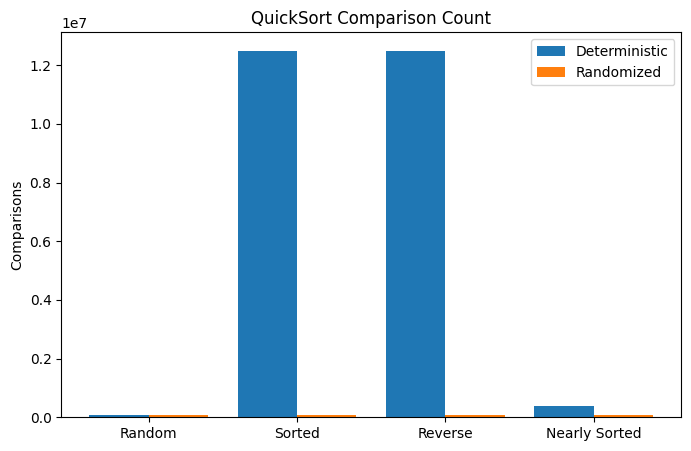

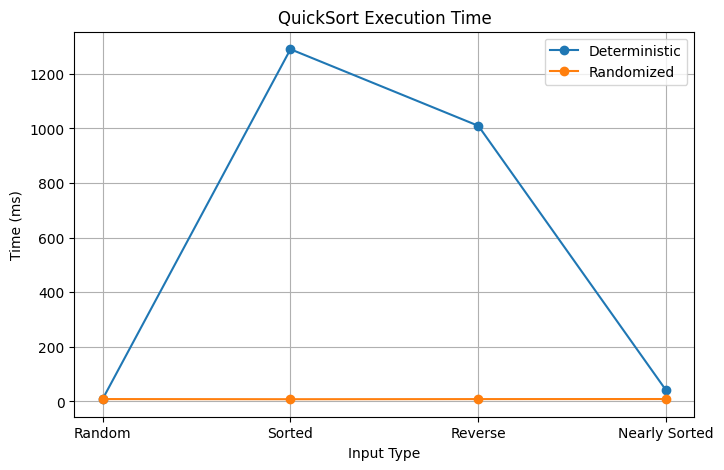

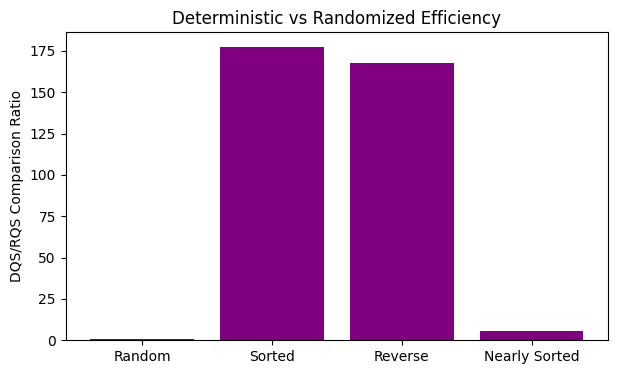

In [9]:
import random
import time
import sys
import matplotlib.pyplot as plt

sys.setrecursionlimit(20000)


comparisons = 0


# -------------------------------------------------
# Partition Function
# -------------------------------------------------
def partition(arr, low, high):

    global comparisons

    pivot = arr[high]

    i = low - 1


    for j in range(low, high):

        comparisons += 1

        if arr[j] <= pivot:

            i += 1

            arr[i], arr[j] = arr[j], arr[i]


    arr[i+1], arr[high] = arr[high], arr[i+1]

    return i+1



# -------------------------------------------------
# Deterministic QuickSort
# -------------------------------------------------
def deterministic_quicksort(arr, low, high):

    if low < high:

        pi = partition(
            arr,
            low,
            high
        )

        deterministic_quicksort(
            arr,
            low,
            pi-1
        )

        deterministic_quicksort(
            arr,
            pi+1,
            high
        )



# -------------------------------------------------
# Randomized QuickSort
# -------------------------------------------------
def randomized_quicksort(arr, low, high):

    if low < high:


        rand_idx = random.randint(
            low,
            high
        )


        arr[rand_idx], arr[high] = (
            arr[high],
            arr[rand_idx]
        )


        pi = partition(
            arr,
            low,
            high
        )


        randomized_quicksort(
            arr,
            low,
            pi-1
        )


        randomized_quicksort(
            arr,
            pi+1,
            high
        )



# -------------------------------------------------
# Testing Function
# -------------------------------------------------
def run_test(sort_fn, arr):

    global comparisons


    a = arr[:]

    comparisons = 0


    start = time.perf_counter()


    sort_fn(
        a,
        0,
        len(a)-1
    )


    elapsed = (
        time.perf_counter()-start
    )*1000


    return comparisons, elapsed



# -------------------------------------------------
# Graph 1 : Comparisons
# -------------------------------------------------
def plot_comparisons(results):

    cases=list(results.keys())


    dqs=[
        results[x][0]
        for x in cases
    ]

    rqs=[
        results[x][2]
        for x in cases
    ]


    x=range(len(cases))


    plt.figure(figsize=(8,5))


    plt.bar(
        [i-0.2 for i in x],
        dqs,
        width=0.4,
        label="Deterministic"
    )


    plt.bar(
        [i+0.2 for i in x],
        rqs,
        width=0.4,
        label="Randomized"
    )


    plt.xticks(
        x,
        cases
    )


    plt.ylabel(
        "Comparisons"
    )


    plt.title(
        "QuickSort Comparison Count"
    )


    plt.legend()

    plt.show()



# -------------------------------------------------
# Graph 2 : Execution Time
# -------------------------------------------------
def plot_time(results):

    cases=list(results.keys())


    dtime=[
        results[x][1]
        for x in cases
    ]


    rtime=[
        results[x][3]
        for x in cases
    ]


    plt.figure(figsize=(8,5))


    plt.plot(
        cases,
        dtime,
        marker='o',
        label="Deterministic"
    )


    plt.plot(
        cases,
        rtime,
        marker='o',
        label="Randomized"
    )


    plt.ylabel(
        "Time (ms)"
    )


    plt.xlabel(
        "Input Type"
    )


    plt.title(
        "QuickSort Execution Time"
    )


    plt.grid(True)

    plt.legend()

    plt.show()



# -------------------------------------------------
# Graph 3 : Performance Summary
# -------------------------------------------------
def plot_ratio(results):

    cases=list(results.keys())


    ratios=[]


    for x in cases:

        ratios.append(
            results[x][0] /
            max(results[x][2],1)
        )


    plt.figure(figsize=(7,4))


    plt.bar(
        cases,
        ratios,
        color="purple"
    )


    plt.ylabel(
        "DQS/RQS Comparison Ratio"
    )


    plt.title(
        "Deterministic vs Randomized Efficiency"
    )


    plt.show()



# =================================================
# MAIN PROGRAM
# =================================================


N = 5000


test_cases = {


    "Random":
    [
        random.randint(1,100000)
        for _ in range(N)
    ],


    "Sorted":
    list(range(N)),


    "Reverse":
    list(range(N,0,-1)),


    "Nearly Sorted":
    list(range(N))

}



# Nearly sorted modification

ns=test_cases["Nearly Sorted"]


for _ in range(N//20):

    i=random.randint(0,N-1)

    j=random.randint(0,N-1)

    ns[i],ns[j]=ns[j],ns[i]



results={}


print(
    f"{'Input Type':<16}"
    f"{'DQS Comp':>12}"
    f"{'DQS Time':>14}"
    f"{'RQS Comp':>12}"
    f"{'RQS Time':>14}"
)


print("-"*70)



for case,arr in test_cases.items():


    d_comp,d_time=run_test(
        deterministic_quicksort,
        arr
    )


    r_comp,r_time=run_test(
        randomized_quicksort,
        arr
    )


    results[case]=(
        d_comp,
        d_time,
        r_comp,
        r_time
    )


    print(
        f"{case:<16}"
        f"{d_comp:>12}"
        f"{d_time:>14.2f}"
        f"{r_comp:>12}"
        f"{r_time:>14.2f}"
    )



# Visualizations

plot_comparisons(results)

plot_time(results)

plot_ratio(results)